# 03. Cleveland: exploratory profile

**Phase 3, Step 1.** Cleveland is the primary sample (see the README's analysis
plan). This notebook *describes* it: how each predictor is distributed, and
how it differs between patients with and without heart disease.

**What this notebook is not:** there are no statistical tests and no model
here. Every comparison is one variable at a time, so a difference seen here
may be partly explained by another variable (for example, if men are older,
an age difference and a sex difference are tangled together). Testing and
adjusting come in the next steps. The purpose here is to know the data well
enough to ask good questions of it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from clean_data import load_clean  # noqa: E402

df = load_clean()
cle = df[df["site"] == "cleveland"].copy()
cle["group"] = cle["disease"].map({False: "No disease", True: "Disease"})

# Chart style: one colour per group, used identically in every chart.
# Validated pair (colour-blind separation dE 24.7, contrast >= 3:1 on the surface).
COLORS = {"No disease": "#2a78d6", "Disease": "#eb6834"}
SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
FIG_DIR = ROOT / "reports" / "figures"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
                     "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
                     "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9})

## 1. The sample

In [2]:
n = len(cle)
n_dis = int(cle["disease"].sum())
print(f"Patients: {n}")
print(f"With disease: {n_dis} ({n_dis / n:.0%})   Without: {n - n_dis} ({1 - n_dis / n:.0%})")
print(f"Flagged possible duplicates: {int(cle['possible_duplicate'].sum())}")
missing = cle.drop(columns=["group"]).isna().sum()
print("Missing values:", missing[missing > 0].to_dict())

Patients: 303
With disease: 139 (46%)   Without: 164 (54%)
Flagged possible duplicates: 0
Missing values: {'major_vessels': 4, 'thallium_result': 2}


The two groups are close to balanced (46% vs 54%), so neither group is so
small that its summaries are unreliable. Only 6 values are missing in the whole
sample, all in `major_vessels` and `thallium_result`; the profile below simply
leaves them out of those two variables rather than dropping the patients.

## 2. Numeric measurements

For each measurement: the typical value in each group. The **median** is the
middle patient; the **IQR** (interquartile range) is the range covering the
middle half of patients. Both are robust to a few extreme values, which
matters for cholesterol (maximum 564 mg/dl). The mean is shown for reference.

In [3]:
NUMERIC = {
    "age": "Age (years)",
    "resting_bp": "Resting blood pressure (mm Hg)",
    "cholesterol": "Cholesterol (mg/dl)",
    "max_heart_rate": "Max heart rate (bpm)",
    "st_depression": "ST depression",
}

def q(p):
    f = lambda s: s.quantile(p)
    f.__name__ = f"q{int(p * 100)}"
    return f

rows = []
for col, label in NUMERIC.items():
    for grp in ["No disease", "Disease"]:
        s = cle.loc[cle["group"] == grp, col].dropna().astype(float)
        rows.append({"measurement": label, "group": grp, "n": len(s),
                     "median": s.median(), "IQR": f"{s.quantile(.25):g}–{s.quantile(.75):g}",
                     "mean": round(s.mean(), 1)})
num_table = pd.DataFrame(rows).set_index(["measurement", "group"])
med = num_table["median"].unstack()
num_table, (med["Disease"] - med["No disease"]).rename("median difference (Disease − No disease)").to_frame()

(                                             n  median            IQR   mean
 measurement                    group                                        
 Age (years)                    No disease  164    52.0       44.75–59   52.6
                                Disease     139    58.0          52–62   56.6
 Resting blood pressure (mm Hg) No disease  164   130.0        120–140  129.2
                                Disease     139   130.0        120–145  134.6
 Cholesterol (mg/dl)            No disease  164   234.5  208.75–267.25  242.6
                                Disease     139   249.0    217.5–283.5  251.5
 Max heart rate (bpm)           No disease  164   161.0     148.75–172  158.4
                                Disease     139   142.0      125–156.5  139.3
 ST depression                  No disease  164     0.2        0–1.025    0.6
                                Disease     139     1.4       0.55–2.5    1.6,
                                 median difference (Disease − N

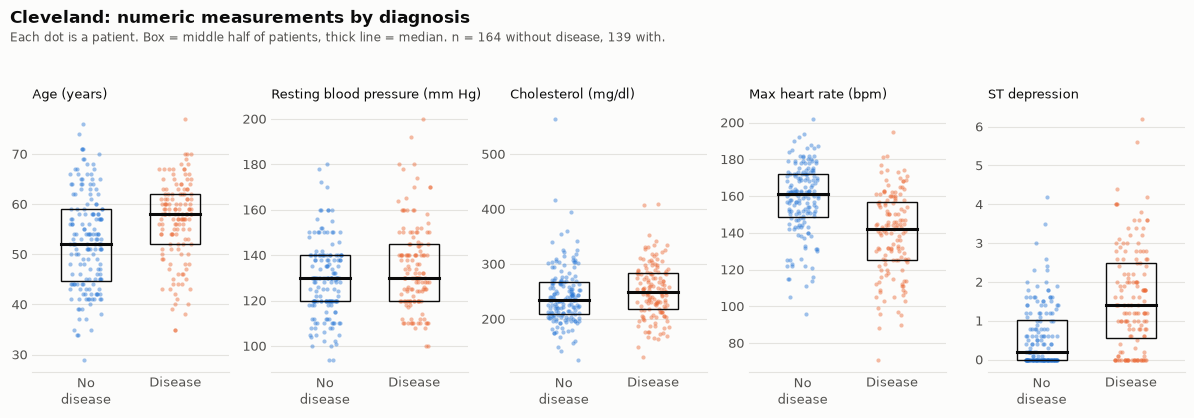

In [4]:
fig, axes = plt.subplots(1, len(NUMERIC), figsize=(12, 4.2))
rng = np.random.default_rng(0)
groups = ["No disease", "Disease"]
for ax, (col, label) in zip(axes, NUMERIC.items()):
    for x, grp in enumerate(groups):
        vals = cle.loc[cle["group"] == grp, col].dropna().astype(float).to_numpy()
        # every patient as a dot (jittered sideways so they don't overlap)
        ax.scatter(x + rng.uniform(-0.18, 0.18, len(vals)), vals, s=9,
                   color=COLORS[grp], alpha=0.45, linewidths=0)
        # box = middle half of patients, thick line = median
        q1, q2, q3 = np.percentile(vals, [25, 50, 75])
        ax.add_patch(plt.Rectangle((x - 0.28, q1), 0.56, q3 - q1, fill=False,
                                   edgecolor=INK, linewidth=1))
        ax.plot([x - 0.28, x + 0.28], [q2, q2], color=INK, linewidth=2.2)
    ax.set_xticks([0, 1], ["No\ndisease", "Disease"])
    ax.set_xlim(-0.6, 1.6)
    ax.set_title(label, fontsize=9.5, color=INK, loc="left")
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
fig.suptitle("Cleveland: numeric measurements by diagnosis", x=0.01, ha="left",
             fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.905, "Each dot is a patient. Box = middle half of patients, thick line = median. "
         "n = 164 without disease, 139 with.", fontsize=8.5, color=INK_2)
fig.tight_layout(rect=(0, 0, 1, 0.9))
fig.savefig(FIG_DIR / "cleveland_numeric_by_diagnosis.png", dpi=200)
plt.show()

### What the numeric measurements show

- **Max heart rate separates the groups most clearly.** Patients with disease
  reached a median of 142 bpm versus 161 bpm without (−19 bpm), and the two
  boxes barely overlap. A heart that can't reach a high rate under exercise is
  a known warning sign, so this is plausible.
- **ST depression is the other strong one.** The median is 1.4 with disease
  versus 0.2 without. Most patients without disease sit at or near 0.
- **Age differs moderately.** Median 58 versus 52, but the groups overlap
  widely: plenty of younger patients have disease and plenty of older ones don't.
- **Cholesterol and resting blood pressure barely differ.** Cholesterol medians
  are 249 versus 234.5, with boxes mostly overlapping; blood pressure medians
  are identical (130). This may look surprising, since both are established
  risk factors. One likely reason: every patient here was **referred for
  angiography**, so the sample is already a high-suspicion group, not the
  general population. A risk factor that separates healthy people from
  patients can look flat *within* a group of patients. Findings here describe
  referred patients only.

## 3. Categorical measurements

For categories, the natural summary is: **of the patients in this category,
what share have heart disease?** Compare each bar with the dashed line, the
46% rate for the whole sample. A bar far from the line means that category is
associated with a very different disease rate. The `n` beside each bar
matters: a category with few patients can land far from the line by chance.

In [5]:
CATEGORICAL = {
    "sex": "Sex",
    "chest_pain_type": "Chest pain type",
    "exercise_angina": "Exercise-induced angina",
    "st_slope": "ST segment slope",
    "major_vessels": "Major vessels coloured (0–3)",
    "thallium_result": "Thallium stress test",
    "resting_ecg": "Resting ECG",
    "fasting_blood_sugar_gt_120": "Fasting blood sugar > 120",
}
tables = {}
for col in CATEGORICAL:
    t = (cle.dropna(subset=[col]).groupby(col, observed=True)["disease"]
         .agg(n="count", with_disease="sum"))
    t["% with disease"] = (t["with_disease"] / t["n"] * 100).round(0).astype(int)
    # readable level names: yes/no for flags, and 0-3 kept as text so the
    # combined table doesn't merge them with the yes/no levels
    if pd.api.types.is_bool_dtype(cle[col]):
        t.index = t.index.map({False: "no", True: "yes"})
    else:
        t.index = t.index.astype(str)
    tables[col] = t
cat_table = pd.concat(tables, names=["variable", "level"])
cat_table

n  with_disease  \
variable                   level                                  
sex                        female              97            25   
                           male               206           114   
chest_pain_type            typical angina      23             7   
                           atypical angina     50             9   
                           non-anginal pain    86            18   
                           asymptomatic       144           105   
exercise_angina            no                 204            63   
                           yes                 99            76   
st_slope                   upsloping          142            36   
                           flat               140            91   
                           downsloping         21            12   
major_vessels              0                  176            46   
                           1                   65            44   
                           2                   38            31   
                           3                   20            17   
thallium_result            normal             166            37   
                           fixed defect        18            12   
                           reversible defect  117            89   
resting_ecg                normal             151            56   
                           ST-T abnormality     4             3   
                           LV hypertrophy     148            80   
fasting_blood_sugar_gt_120 no                 258           117   
                           yes                 45            22   

                                              % with disease  
variable                   level                              
sex                        female                         26  
                           male                           55  
chest_pain_type            typical angina                 30  
                           atypical angina                18  
                           non-anginal pain               21  
                           asymptomatic                   73  
exercise_angina            no                             31  
                           yes                            77  
st_slope                   upsloping                      25  
                           flat                           65  
                           downsloping                    57  
major_vessels              0                              26  
                           1                              68  
                           2                              82  
                           3                              85  
thallium_result            normal                         22  
                           fixed defect                   67  
                           reversible defect              76  
resting_ecg                normal                         37  
                           ST-T abnormality               75  
                           LV hypertrophy                 54  
fasting_blood_sugar_gt_120 no                             45  
                           yes                            49

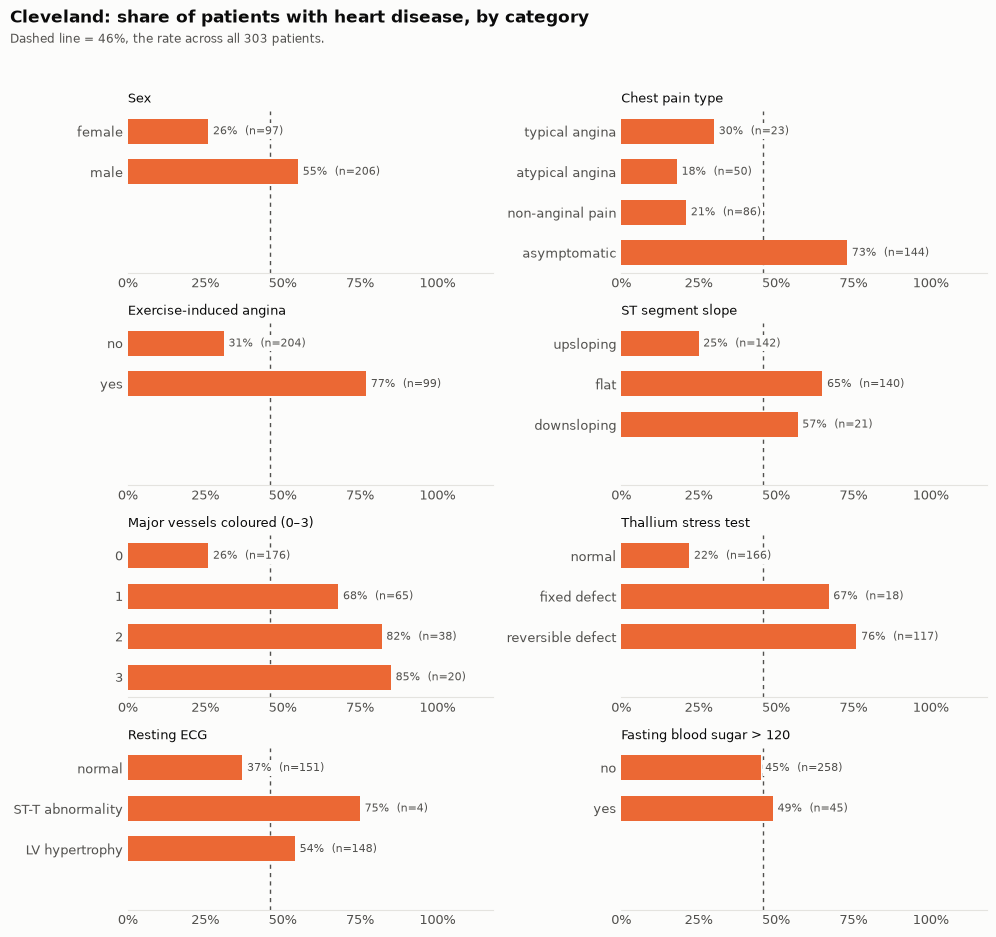

In [6]:
overall = cle["disease"].mean() * 100
fig, axes = plt.subplots(4, 2, figsize=(10, 9.5))
for ax, (col, label) in zip(axes.flat, CATEGORICAL.items()):
    t = tables[col].iloc[::-1]  # first level at the top
    levels = [str(v) for v in t.index]
    y = np.arange(len(t))
    ax.axvline(overall, color=INK_2, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
    ax.barh(y, t["% with disease"], height=0.62, color=COLORS["Disease"], zorder=2)
    for yi, (pct, cnt) in enumerate(zip(t["% with disease"], t["n"])):
        # surface-coloured box so the reference line never runs through a label
        ax.text(pct + 1.5, yi, f"{pct}%  (n={cnt})", va="center", fontsize=8, color=INK_2,
                zorder=3, bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.5))
    ax.set_yticks(y, levels)
    # same row height in every panel (room for 4 levels), levels packed at the top
    ax.set_ylim(len(t) - 4.5, len(t) - 0.5)
    ax.set_xlim(0, 118)
    ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
    ax.set_title(label, fontsize=9.5, color=INK, loc="left")
    ax.tick_params(length=0)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
fig.suptitle("Cleveland: share of patients with heart disease, by category", x=0.01,
             ha="left", fontsize=12, fontweight="bold", color=INK)
fig.text(0.01, 0.945, f"Dashed line = {overall:.0f}%, the rate across all 303 patients.",
         fontsize=8.5, color=INK_2)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIG_DIR / "cleveland_categorical_disease_rate.png", dpi=200)
plt.show()

### What the categories show

- **Major vessels coloured rises step by step:** 26% disease with 0 vessels,
  68% with 1, 82% with 2, 85% with 3. A steady climb like this is more
  convincing than a single jump.
- **Thallium result:** 22% disease when normal versus 76% with a reversible
  defect.
- **Exercise-induced angina:** 77% with it versus 31% without.
- **ST slope:** 25% for upsloping versus 65% for flat.
- **Sex:** 55% of men versus 26% of women.
- **Chest pain type runs against intuition:** *asymptomatic* patients have the
  highest rate (73%) and *typical angina* one of the lowest (30%). A plausible
  explanation is how these patients reached angiography: someone without chest
  pain was likely referred because another test was already abnormal. That is
  a hypothesis, not something this data can show.
- **Weak or unreliable:** fasting blood sugar barely moves the rate (49% vs
  45%). Resting ECG "ST-T abnormality" shows 75%, but that is 3 of just 4
  patients, far too few to read anything into.

**A caution about the two strongest variables.** `major_vessels` (vessels seen
on fluoroscopy) and `thallium_result` come from imaging that is close to the
diagnostic procedure itself. They are strongly associated with disease partly
because they measure nearly the same thing. They are still informative, but a
finding like "vessel count predicts disease" is much less useful than one about
a measurement taken *before* specialised imaging, such as heart rate or exercise
angina.

## Summary and next step

| Strength of the one-variable difference | Variables |
|---|---|
| **Strong** | max heart rate, ST depression, major vessels, thallium result, exercise angina, chest pain type, ST slope |
| **Moderate** | sex, age, resting ECG |
| **Little or none** | cholesterol, resting blood pressure, fasting blood sugar |

Three limits apply to everything above:

1. **One variable at a time.** Differences may overlap. For example, if men
   in this sample are also more likely to have exercise angina, the sex gap
   and the angina gap are partly the same gap.
2. **Referred patients only**, as explained under the numeric results.
3. **No uncertainty yet.** A 30% versus 18% difference between groups of
   23 and 50 patients could easily be chance. "Strong" above is a visual
   judgement.

**Next step (Phase 3, Step 2):** put numbers on point 3. For each variable,
the size of the difference with a confidence interval, and a test of whether
it could plausibly be chance, with a correction for testing 13 variables at
once.